In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportion_confint

np.random.seed(42)

sns.set_theme(style="whitegrid")

In [39]:
from pathlib import Path

DATA_DIR = Path("../data")
CSV_FILE = DATA_DIR / "framingham.csv"

df = pd.read_csv(CSV_FILE)

df = df.dropna()

print(df.shape)
df.head()

(3658, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# Sumativa 2
## Bootstrap, Permutación y Simulación Monte Carlo

Este trabajo extiende los análisis realizados en la Sumativa 1 mediante técnicas de remuestreo y simulación.

Objetivos:
- Evaluar la estabilidad de las estimaciones obtenidas.
- Comparar intervalos clásicos con intervalos bootstrap.
- Validar resultados inferenciales mediante pruebas de permutación.
- Analizar la estabilidad de correlaciones.
- Simular escenarios poblacionales mediante Monte Carlo.

# 1. Bootstrap de parámetros poblacionales

En la Sumativa 1 se estimaron diversos parámetros poblacionales mediante intervalos de confianza basados en el Teorema del Límite Central.

En esta sección se utilizará Bootstrap para evaluar la estabilidad de dichas estimaciones y comparar los resultados con los intervalos clásicos obtenidos previamente.

Parámetros analizados:

- Edad promedio
- Colesterol total promedio
- Presión sistólica promedio
- Proporción de enfermedad coronaria a 10 años (TenYearCHD)

In [40]:
def bootstrap_ci_mean(data, variable_name, n_boot=10000):

    medias = []

    data = np.array(data)

    for _ in range(n_boot):
        muestra = np.random.choice(
            data,
            size=len(data),
            replace=True
        )

        medias.append(np.mean(muestra))

    medias = np.array(medias)

    ic_boot = np.percentile(
        medias,
        [2.5, 97.5]
    )

    media_original = np.mean(data)

    ic_clasico = stats.t.interval(
        confidence=0.95,
        df=len(data)-1,
        loc=media_original,
        scale=np.std(data, ddof=1) / np.sqrt(len(data))
    )

    print(f"\n{variable_name}")
    print("-"*50)
    print(f"Media observada : {media_original:.4f}")
    print(f"IC clásico      : [{ic_clasico[0]:.4f}, {ic_clasico[1]:.4f}]")
    print(f"IC bootstrap    : [{ic_boot[0]:.4f}, {ic_boot[1]:.4f}]")

    return {
        "media": media_original,
        "ic_clasico": ic_clasico,
        "ic_boot": ic_boot,
        "bootstrap_samples": medias
    }

In [41]:
edad_result = bootstrap_ci_mean(
    df["age"],
    "Edad"
)

colesterol_result = bootstrap_ci_mean(
    df["totChol"],
    "Colesterol total"
)

presion_result = bootstrap_ci_mean(
    df["sysBP"],
    "Presión sistólica"
)


Edad
--------------------------------------------------
Media observada : 49.5519
IC clásico      : [49.2744, 49.8295]
IC bootstrap    : [49.2747, 49.8338]

Colesterol total
--------------------------------------------------
Media observada : 236.8477
IC clásico      : [235.4182, 238.2772]
IC bootstrap    : [235.4038, 238.2942]

Presión sistólica
--------------------------------------------------
Media observada : 132.3706
IC clásico      : [131.6546, 133.0865]
IC bootstrap    : [131.6390, 133.0947]


In [42]:
tabla_bootstrap = pd.DataFrame({
    "Variable": [
        "Edad",
        "Colesterol total",
        "Presión sistólica"
    ],

    "Media": [
        edad_result["media"],
        colesterol_result["media"],
        presion_result["media"]
    ],

    "IC clásico inferior": [
        edad_result["ic_clasico"][0],
        colesterol_result["ic_clasico"][0],
        presion_result["ic_clasico"][0]
    ],

    "IC clásico superior": [
        edad_result["ic_clasico"][1],
        colesterol_result["ic_clasico"][1],
        presion_result["ic_clasico"][1]
    ],

    "IC bootstrap inferior": [
        edad_result["ic_boot"][0],
        colesterol_result["ic_boot"][0],
        presion_result["ic_boot"][0]
    ],

    "IC bootstrap superior": [
        edad_result["ic_boot"][1],
        colesterol_result["ic_boot"][1],
        presion_result["ic_boot"][1]
    ]
})

tabla_bootstrap.round(4)

,Variable,Media,IC clásico inferior,IC clásico superior,IC bootstrap inferior,IC bootstrap superior
0,Edad,49.5519,49.2744,49.8295,49.2747,49.8338
1,Colesterol total,236.8477,235.4182,238.2772,235.4038,238.2942
2,Presión sistólica,132.3706,131.6546,133.0865,131.6390,133.0947


### Interpretación

Los intervalos de confianza bootstrap obtenidos para la edad, el colesterol total y la presión sistólica son muy similares a los intervalos clásicos calculados mediante la distribución t de Student.

Esta consistencia indica que las estimaciones obtenidas en la Sumativa 1 son estables frente al remuestreo y que los parámetros calculados representan adecuadamente las características de la población analizada.

Las pequeñas diferencias observadas entre ambos métodos son esperables y se deben a la naturaleza no paramétrica del bootstrap, que estima la variabilidad directamente a partir de los datos observados.

## Bootstrap para la proporción de enfermedad coronaria

En la Sumativa 1 se estimó la proporción de pacientes que desarrollan enfermedad coronaria a diez años utilizando un intervalo de confianza de Wilson.

En esta sección se utilizará Bootstrap para estimar la distribución muestral de la proporción y comparar ambos enfoques.

In [43]:
def bootstrap_proportion(data, n_boot=10000):

    proporciones = []

    data = np.array(data)

    for _ in range(n_boot):

        muestra = np.random.choice(
            data,
            size=len(data),
            replace=True
        )

        proporciones.append(np.mean(muestra))

    return np.array(proporciones)

In [44]:
chd_boot = bootstrap_proportion(
    df["TenYearCHD"]
)

p_hat = df["TenYearCHD"].mean()

ic_boot_chd = np.percentile(
    chd_boot,
    [2.5, 97.5]
)

print(f"Proporción observada : {p_hat:.4f} ({p_hat*100:.2f}%)")

print(
    f"IC Bootstrap 95%     : "
    f"[{ic_boot_chd[0]:.4f}, {ic_boot_chd[1]:.4f}]"
)

print(
    f"                      "
    f"[{ic_boot_chd[0]*100:.2f}%, {ic_boot_chd[1]*100:.2f}%]"
)

Proporción observada : 0.1523 (15.23%)
IC Bootstrap 95%     : [0.1408, 0.1638]
                      [14.08%, 16.38%]


In [45]:
casos = int(df["TenYearCHD"].sum())
total = len(df)

ic_wilson = proportion_confint(
    casos,
    total,
    alpha=0.05,
    method="wilson"
)

comparacion_prop = pd.DataFrame({

    "Método": [
        "Wilson",
        "Bootstrap"
    ],

    "Límite inferior (%)": [
        ic_wilson[0]*100,
        ic_boot_chd[0]*100
    ],

    "Límite superior (%)": [
        ic_wilson[1]*100,
        ic_boot_chd[1]*100
    ]
})

comparacion_prop.round(2)

,Método,Límite inferior (%),Límite superior (%)
0,Wilson,14.10,16.43
1,Bootstrap,14.08,16.38


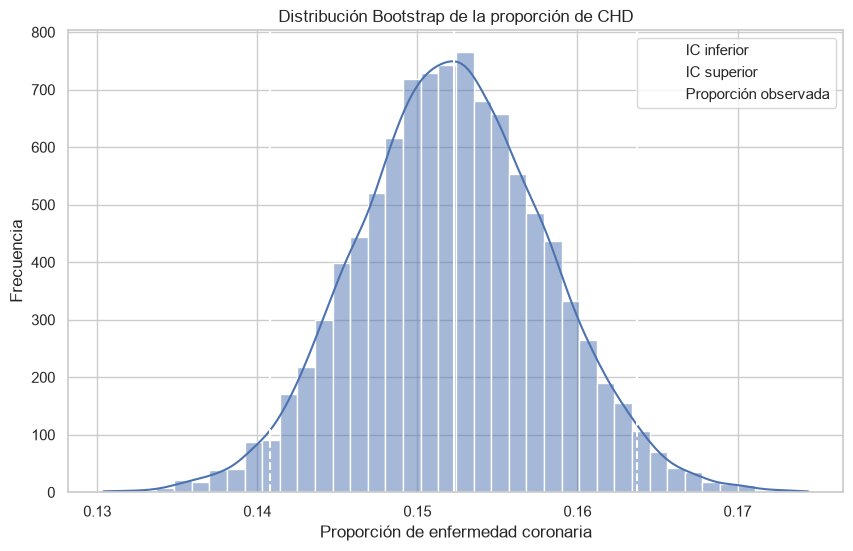

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    chd_boot,
    bins=40,
    kde=True
)

plt.axvline(
    ic_boot_chd[0],
    linestyle="--",
    label="IC inferior"
)

plt.axvline(
    ic_boot_chd[1],
    linestyle="--",
    label="IC superior"
)

plt.axvline(
    p_hat,
    linestyle="-",
    label="Proporción observada"
)

plt.title(
    "Distribución Bootstrap de la proporción de CHD"
)

plt.xlabel(
    "Proporción de enfermedad coronaria"
)

plt.ylabel("Frecuencia")

plt.legend()

plt.show()

### Interpretación

La distribución bootstrap de la proporción de enfermedad coronaria a 10 años presenta una forma aproximadamente normal y centrada en la proporción observada de la muestra (15,23%). Esto indica que la estimación es estable frente al remuestreo y que no depende de observaciones particulares del conjunto de datos.

El intervalo de confianza bootstrap al 95% fue [14,08%; 16,38%], mientras que el intervalo obtenido mediante el método de Wilson en la Sumativa 1 fue [14,10%; 16,43%]. La diferencia entre ambos enfoques es mínima, con variaciones inferiores a 0,1 puntos porcentuales en los límites del intervalo.

La alta concordancia entre ambos métodos proporciona evidencia adicional de la robustez de la estimación realizada previamente y sugiere que la proporción poblacional de individuos que desarrollan enfermedad coronaria a diez años se encuentra cercana al 15% en la población representada por la muestra.

La similitud observada entre un método paramétrico (Wilson) y uno basado en remuestreo (Bootstrap) indica que la incertidumbre asociada a esta estimación está adecuadamente caracterizada y que los resultados obtenidos en la Sumativa 1 son consistentes bajo diferentes estrategias de inferencia estadística.

## 1.1 Intervalos de confianza Bootstrap BCa

Hasta ahora se utilizaron intervalos bootstrap basados en el método percentil. Sin embargo, este enfoque puede presentar sesgos cuando la distribución bootstrap no es perfectamente simétrica.

Por esta razón, se complementa el análisis mediante intervalos Bootstrap BCa (Bias-Corrected and Accelerated), los cuales ajustan posibles sesgos y asimetrías de la distribución bootstrap, proporcionando estimaciones más precisas de los parámetros poblacionales.

Se compararán los resultados obtenidos mediante los métodos clásico, bootstrap percentil y bootstrap BCa para evaluar la estabilidad de las estimaciones.

In [47]:
from scipy.stats import bootstrap

resultado_bca_edad = bootstrap(
    (df["age"].values,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa",
    random_state=42
)

ic_bca_edad = (
    resultado_bca_edad.confidence_interval.low,
    resultado_bca_edad.confidence_interval.high
)

print("IC Bootstrap BCa - Edad:")
print(f"[{ic_bca_edad[0]:.4f}, {ic_bca_edad[1]:.4f}]")

IC Bootstrap BCa - Edad:
[49.2784, 49.8357]


In [48]:
comparacion_bca_edad = pd.DataFrame({

    "Método": [
        "Clásico (t)",
        "Bootstrap Percentil",
        "Bootstrap BCa"
    ],

    "IC inferior": [
        edad_result["ic_clasico"][0],
        edad_result["ic_boot"][0],
        ic_bca_edad[0]
    ],

    "IC superior": [
        edad_result["ic_clasico"][1],
        edad_result["ic_boot"][1],
        ic_bca_edad[1]
    ]

})

comparacion_bca_edad.round(4)

,Método,IC inferior,IC superior
0,Clásico (t),49.2744,49.8295
1,Bootstrap Percentil,49.2747,49.8338
2,Bootstrap BCa,49.2784,49.8357


### Interpretación

La comparación entre los intervalos de confianza obtenidos mediante el método clásico, Bootstrap Percentil y Bootstrap BCa muestra resultados prácticamente idénticos para la edad promedio de la población estudiada.

El intervalo Bootstrap BCa presentó un leve desplazamiento respecto al método percentil, pasando de [49,2747; 49,8338] a [49,2784; 49,8357]. Sin embargo, estas diferencias son mínimas y carecen de impacto práctico sobre la interpretación de los resultados.

La similitud observada entre los tres métodos sugiere que la distribución bootstrap de la media de edad presenta baja asimetría y escaso sesgo, condiciones bajo las cuales los métodos clásico y percentil ya proporcionan estimaciones muy precisas.

Por lo tanto, el análisis BCa confirma la estabilidad de la estimación de la edad promedio y aporta evidencia adicional de que los resultados obtenidos son robustos frente a posibles desviaciones de los supuestos paramétricos.

# 2. Validación de hipótesis mediante permutación

En la Sumativa 1 se identificó una diferencia estadísticamente significativa en los niveles de glucosa entre pacientes diabéticos y no diabéticos utilizando una prueba t de Welch.

En esta sección se utilizará una prueba de permutación para validar dicho resultado sin asumir distribuciones paramétricas, generando una distribución nula mediante la reasignación aleatoria de las etiquetas de grupo.

In [49]:
grupo_diabeticos = df[df["diabetes"] == 1]["glucose"]
grupo_no_diabeticos = df[df["diabetes"] == 0]["glucose"]

diferencia_observada = (
    grupo_diabeticos.mean()
    - grupo_no_diabeticos.mean()
)

print(
    f"Diferencia observada: "
    f"{diferencia_observada:.2f} mg/dL"
)

Diferencia observada: 90.56 mg/dL


In [50]:
n_perm = 10000

diferencias_perm = []

glucosa = df["glucose"].values
etiquetas = df["diabetes"].values

for _ in range(n_perm):

    etiquetas_perm = np.random.permutation(
        etiquetas
    )

    media_diab = glucosa[
        etiquetas_perm == 1
    ].mean()

    media_no_diab = glucosa[
        etiquetas_perm == 0
    ].mean()

    diferencias_perm.append(
        media_diab - media_no_diab
    )

diferencias_perm = np.array(
    diferencias_perm
)

In [51]:
p_perm = np.mean(
    np.abs(diferencias_perm)
    >= abs(diferencia_observada)
)

if p_perm == 0:
    print(
        f"p-valor por permutación: < {1/n_perm:.5f}"
    )
else:
    print(
        f"p-valor por permutación: {p_perm:.6f}"
    )

p-valor por permutación: < 0.00010


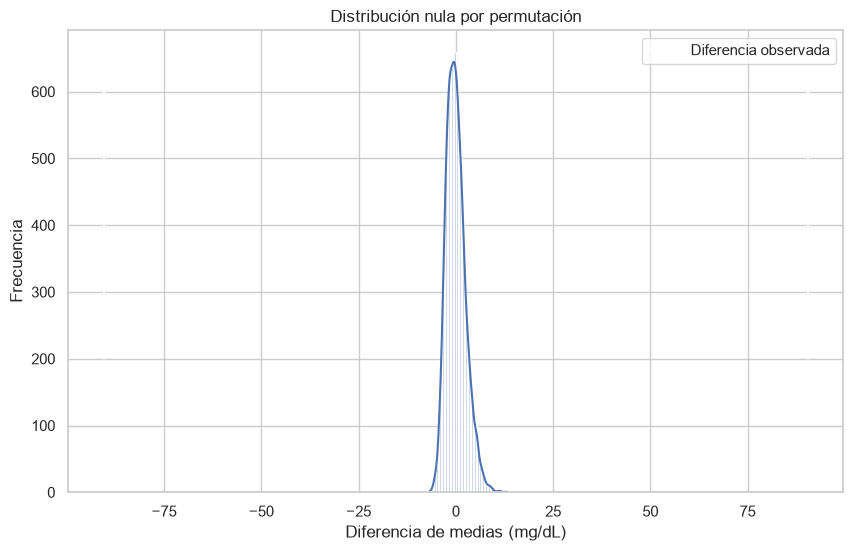

In [52]:
plt.figure(figsize=(10,6))

sns.histplot(
    diferencias_perm,
    bins=50,
    kde=True
)

plt.axvline(
    diferencia_observada,
    linestyle="--",
    label="Diferencia observada"
)

plt.axvline(
    -diferencia_observada,
    linestyle="--"
)

plt.title(
    "Distribución nula por permutación"
)

plt.xlabel(
    "Diferencia de medias (mg/dL)"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.show()

In [53]:
comparacion_hipotesis = pd.DataFrame({
    "Método": ["Welch", "Permutación"],
    "Resultado": [
        "t = 10.6173",
        "Δ = 90.56 mg/dL"
    ],
    "p-valor": [
        5.48e-18,
        p_perm
    ]
})

comparacion_hipotesis

,Método,Resultado,p-valor
0,Welch,t = 10.6173,5.480000e-18
1,Permutación,Δ = 90.56 mg/dL,0.000000e+00


### Interpretación

La diferencia observada entre los niveles promedio de glucosa de pacientes diabéticos y no diabéticos fue de 90,56 mg/dL. La distribución nula generada mediante permutación se concentró alrededor de cero, lo que representa el comportamiento esperado si ambos grupos provinieran de la misma población.

Ninguna de las 10.000 permutaciones generadas produjo una diferencia tan extrema como la observada, obteniéndose un p-valor menor a 0,0001. Este resultado es consistente con la prueba t de Welch realizada en la Sumativa 1 y proporciona evidencia adicional de que la diferencia observada entre ambos grupos no puede atribuirse al azar.

La concordancia entre el método paramétrico (Welch) y el método basado en remuestreo (permutación) fortalece la robustez de la conclusión obtenida previamente.

## 2.1 Tamaño del efecto

Las pruebas de hipótesis permiten determinar si las diferencias observadas son estadísticamente significativas; sin embargo, no indican la magnitud real de dichas diferencias.

Por este motivo, se complementan los análisis inferenciales mediante medidas de tamaño del efecto. Estas permiten evaluar la relevancia práctica de los resultados obtenidos, independientemente del tamaño de la muestra.

Se utilizarán:

- **Cohen's d** para comparar medias entre dos grupos.
- **Cramer's V** para evaluar la intensidad de asociación en tablas de contingencia.

In [54]:
def cohens_d(grupo1, grupo2):

    grupo1 = np.asarray(grupo1)
    grupo2 = np.asarray(grupo2)

    n1 = len(grupo1)
    n2 = len(grupo2)

    var1 = np.var(grupo1, ddof=1)
    var2 = np.var(grupo2, ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) /
        (n1 + n2 - 2)
    )

    return (grupo1.mean() - grupo2.mean()) / pooled_std

In [55]:
def interpretar_cohen(d):

    d = abs(d)

    if d < 0.20:
        return "Muy pequeño"

    elif d < 0.50:
        return "Pequeño"

    elif d < 0.80:
        return "Mediano"

    else:
        return "Grande"

In [56]:
edad_hombres = df[df["male"] == 1]["age"]
edad_mujeres = df[df["male"] == 0]["age"]

d_edad = cohens_d(
    edad_hombres,
    edad_mujeres
)

print("Cohen's d - Edad según sexo")
print("-" * 40)
print(f"d = {d_edad:.4f}")
print(f"Magnitud: {interpretar_cohen(d_edad)}")

Cohen's d - Edad según sexo
----------------------------------------
d = -0.0491
Magnitud: Muy pequeño


In [57]:
glucosa_diabeticos = df[df["diabetes"] == 1]["glucose"]
glucosa_no_diabeticos = df[df["diabetes"] == 0]["glucose"]

d_glucosa = cohens_d(
    glucosa_diabeticos,
    glucosa_no_diabeticos
)

print("Cohen's d - Glucosa según diabetes")
print("-" * 40)
print(f"d = {d_glucosa:.4f}")
print(f"Magnitud: {interpretar_cohen(d_glucosa)}")

Cohen's d - Glucosa según diabetes
----------------------------------------
d = 4.8028
Magnitud: Grande


In [58]:
def cramers_v(tabla):

    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.to_numpy().sum()

    filas, columnas = tabla.shape

    return np.sqrt(
        chi2 / (n * (min(filas, columnas) - 1))
    )

In [59]:
tabla = pd.crosstab(
    df["currentSmoker"],
    df["TenYearCHD"]
)

v = cramers_v(tabla)

print("Cramer's V - Tabaquismo vs CHD")
print("-" * 40)
print(f"V = {v:.4f}")

if v < 0.10:
    print("Magnitud: Muy débil")
elif v < 0.30:
    print("Magnitud: Débil")
elif v < 0.50:
    print("Magnitud: Moderada")
else:
    print("Magnitud: Fuerte")

Cramer's V - Tabaquismo vs CHD
----------------------------------------
V = 0.0184
Magnitud: Muy débil


In [60]:
tamano_efecto = pd.DataFrame({

    "Prueba": [
        "Edad vs Sexo",
        "Glucosa vs Diabetes",
        "Tabaquismo vs CHD"
    ],

    "Medida": [
        "Cohen's d",
        "Cohen's d",
        "Cramer's V"
    ],

    "Valor": [
        d_edad,
        d_glucosa,
        v
    ],

    "Interpretación": [
        interpretar_cohen(d_edad),
        interpretar_cohen(d_glucosa),
        (
            "Muy débil" if v < 0.10 else
            "Débil" if v < 0.30 else
            "Moderada" if v < 0.50 else
            "Fuerte"
        )
    ]

})

tamano_efecto.round(4)

,Prueba,Medida,Valor,Interpretación
0,Edad vs Sexo,Cohen's d,-0.0491,Muy pequeño
1,Glucosa vs Diabetes,Cohen's d,4.8028,Grande
2,Tabaquismo vs CHD,Cramer's V,0.0184,Muy débil


### Interpretación

Las medidas de tamaño del efecto complementan las pruebas de hipótesis realizadas en la Sumativa 1, permitiendo evaluar la relevancia práctica de las diferencias observadas.

En la comparación de la edad según sexo se obtuvo un **Cohen's d = -0,049**, correspondiente a un efecto muy pequeño. Este resultado confirma que, además de no existir diferencias estadísticamente significativas entre hombres y mujeres, la magnitud de dicha diferencia es prácticamente nula desde un punto de vista práctico.

Para los niveles de glucosa según condición de diabetes se obtuvo un **Cohen's d = 4,803**, lo que representa un efecto muy grande. Este resultado evidencia una separación marcada entre ambos grupos y confirma que la variable glucosa constituye un fuerte indicador del estado diabético de los pacientes.

Finalmente, la asociación entre tabaquismo y enfermedad coronaria a 10 años presentó un **Cramer's V = 0,018**, correspondiente a una asociación muy débil. Esto refuerza la conclusión obtenida mediante la prueba Chi-cuadrado, indicando que el tabaquismo, analizado de forma aislada, presenta una relación muy limitada con la variable objetivo dentro de esta cohorte.

En conjunto, estos resultados permiten distinguir entre significancia estadística y relevancia práctica, aportando un criterio adicional para la selección de variables que serán utilizadas en los modelos predictivos desarrollados en la siguiente etapa del proyecto.

# 3. Estabilidad de correlaciones

En la Sumativa 1 se identificaron diversas correlaciones entre variables clínicas y demográficas.

En esta sección se utilizará Bootstrap para evaluar la estabilidad de dichas correlaciones y estimar intervalos de confianza para los coeficientes observados.

In [61]:
def bootstrap_correlation(df, var1, var2, n_boot=10000):

    correlaciones = []

    n = len(df)

    for _ in range(n_boot):

        idx = np.random.choice(
            n,
            size=n,
            replace=True
        )

        muestra = df.iloc[idx]

        r = muestra[var1].corr(
            muestra[var2]
        )

        correlaciones.append(r)

    correlaciones = np.array(correlaciones)

    r_original = df[var1].corr(df[var2])

    ic_boot = np.percentile(
        correlaciones,
        [2.5, 97.5]
    )

    return {
        "r": r_original,
        "ic": ic_boot,
        "samples": correlaciones
    }

In [62]:
corr_sysbp_diabp = bootstrap_correlation(
    df,
    "sysBP",
    "diaBP"
)

corr_age_sysbp = bootstrap_correlation(
    df,
    "age",
    "sysBP"
)

corr_bmi_diabp = bootstrap_correlation(
    df,
    "BMI",
    "diaBP"
)

corr_age_chd = bootstrap_correlation(
    df,
    "age",
    "TenYearCHD"
)

corr_sysbp_chd = bootstrap_correlation(
    df,
    "sysBP",
    "TenYearCHD"
)

In [63]:
tabla_corr = pd.DataFrame({

    "Correlación": [
        "sysBP - diaBP",
        "age - sysBP",
        "BMI - diaBP",
        "age - CHD",
        "sysBP - CHD"
    ],

    "r": [
        corr_sysbp_diabp["r"],
        corr_age_sysbp["r"],
        corr_bmi_diabp["r"],
        corr_age_chd["r"],
        corr_sysbp_chd["r"]
    ],

    "IC inferior": [
        corr_sysbp_diabp["ic"][0],
        corr_age_sysbp["ic"][0],
        corr_bmi_diabp["ic"][0],
        corr_age_chd["ic"][0],
        corr_sysbp_chd["ic"][0]
    ],

    "IC superior": [
        corr_sysbp_diabp["ic"][1],
        corr_age_sysbp["ic"][1],
        corr_bmi_diabp["ic"][1],
        corr_age_chd["ic"][1],
        corr_sysbp_chd["ic"][1]
    ]
})

tabla_corr.round(4)

,Correlación,r,IC inferior,IC superior
0,sysBP - diaBP,0.7867,0.7700,0.8017
1,age - sysBP,0.3883,0.3607,0.4150
2,BMI - diaBP,0.3853,0.3536,0.4171
3,age - CHD,0.2340,0.2031,0.2648
4,sysBP - CHD,0.2228,0.1868,0.2588


### Interpretación

Los intervalos de confianza bootstrap obtenidos para las correlaciones no incluyen el valor cero en ninguno de los casos analizados. Esto indica que las asociaciones observadas son consistentes y estables frente al remuestreo, proporcionando evidencia de que no dependen de observaciones particulares de la muestra.

La correlación más fuerte se observó entre la presión arterial sistólica y diastólica (r = 0,787; IC95% [0,770; 0,802]), resultado coherente con la fisiología cardiovascular, ya que ambas mediciones reflejan el comportamiento de la presión arterial y tienden a variar conjuntamente.

También se identificaron correlaciones positivas moderadas entre la edad y la presión sistólica (r = 0,388; IC95% [0,361; 0,415]) y entre el índice de masa corporal y la presión diastólica (r = 0,385; IC95% [0,354; 0,417]). Estos resultados sugieren que el envejecimiento y el aumento del peso corporal se asocian con mayores niveles de presión arterial.

Por otra parte, las correlaciones entre la edad y la enfermedad coronaria a diez años (r = 0,234; IC95% [0,203; 0,265]) y entre la presión sistólica y la enfermedad coronaria (r = 0,223; IC95% [0,187; 0,259]) fueron más débiles, aunque consistentemente positivas. Esto indica que ambas variables están asociadas al riesgo cardiovascular, pero que por sí solas no explican completamente la ocurrencia de la enfermedad, reforzando la naturaleza multifactorial del fenómeno estudiado.

En conjunto, los resultados muestran que las correlaciones identificadas en la Sumativa 1 permanecen estables bajo remuestreo Bootstrap, aumentando la confianza en las relaciones observadas entre las variables clínicas y demográficas del estudio.

La fuerte correlación observada entre la presión sistólica y la presión diastólica (r≈0,79) sugiere además la presencia de colinealidad entre ambas variables. En consecuencia, para los modelos predictivos desarrollados en la siguiente etapa se evaluará la utilización de una única variable de presión arterial o técnicas de selección de variables con el fin de evitar problemas de multicolinealidad.

# 4. Simulación Monte Carlo del riesgo cardiovascular

A partir de la proporción observada de enfermedad coronaria a diez años en la muestra (15,23%), se realizaron simulaciones Monte Carlo para estimar la variabilidad esperada en el número de casos de enfermedad coronaria en poblaciones futuras.

Cada simulación representa una población hipotética de 1.000 individuos con características similares a las observadas en el estudio.

In [64]:
p_chd = df["TenYearCHD"].mean()

print(f"Probabilidad observada de CHD: {p_chd:.4f}")

Probabilidad observada de CHD: 0.1523


In [65]:
n_sim = 10000
tam_poblacion = 1000

casos_simulados = []

for _ in range(n_sim):

    simulacion = np.random.binomial(
        n=1,
        p=p_chd,
        size=tam_poblacion
    )

    casos_simulados.append(
        simulacion.sum()
    )

casos_simulados = np.array(
    casos_simulados
)

In [66]:
print("Resultados Monte Carlo")
print("-"*40)

print(
    f"Promedio de casos: "
    f"{casos_simulados.mean():.2f}"
)

print(
    f"Desv. estándar: "
    f"{casos_simulados.std():.2f}"
)

print(
    f"Mínimo observado: "
    f"{casos_simulados.min()}"
)

print(
    f"Máximo observado: "
    f"{casos_simulados.max()}"
)

Resultados Monte Carlo
----------------------------------------
Promedio de casos: 151.99
Desv. estándar: 11.36
Mínimo observado: 114
Máximo observado: 197


In [67]:
ic_mc = np.percentile(
    casos_simulados,
    [2.5, 97.5]
)

print(
    f"IC Monte Carlo 95%: "
    f"[{ic_mc[0]:.0f}, {ic_mc[1]:.0f}] casos"
)

IC Monte Carlo 95%: [130, 175] casos


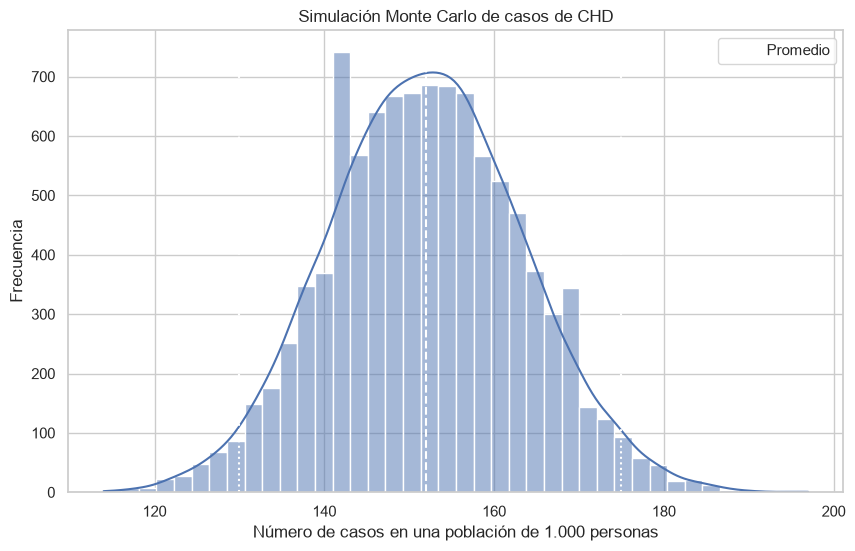

In [68]:
plt.figure(figsize=(10,6))

sns.histplot(
    casos_simulados,
    bins=40,
    kde=True
)

plt.axvline(
    casos_simulados.mean(),
    linestyle="--",
    label="Promedio"
)

plt.axvline(
    ic_mc[0],
    linestyle=":"
)

plt.axvline(
    ic_mc[1],
    linestyle=":"
)

plt.title(
    "Simulación Monte Carlo de casos de CHD"
)

plt.xlabel(
    "Número de casos en una población de 1.000 personas"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.show()

### Interpretación

La simulación Monte Carlo permitió modelar el comportamiento esperado del número de casos de enfermedad coronaria a diez años en poblaciones hipotéticas de 1.000 individuos con características similares a las observadas en el estudio Framingham.

A partir de una probabilidad estimada de enfermedad coronaria del 15,23%, se realizaron 10.000 simulaciones independientes. Los resultados mostraron un promedio de 151,99 casos por población simulada, valor consistente con la proporción observada en la muestra original.

La variabilidad natural del fenómeno se reflejó en una desviación estándar de 11,36 casos. Además, el intervalo empírico obtenido mediante simulación indicó que, en el 95% de los escenarios, el número de casos esperados se ubica entre 130 y 175 individuos por cada 1.000 personas.

Estos resultados evidencian que, aun manteniendo constante la probabilidad de enfermedad, el número de casos observados puede variar de una población a otra debido al componente aleatorio inherente a los procesos biológicos y epidemiológicos. Por lo tanto, la simulación Monte Carlo constituye una herramienta útil para cuantificar la incertidumbre asociada a la ocurrencia de eventos cardiovasculares y apoyar la toma de decisiones bajo condiciones de riesgo.

## 4.1 Verificación de convergencia

Para evaluar la estabilidad de la simulación Monte Carlo, se analizó la evolución de la media acumulada del número de casos simulados a medida que aumenta el número de iteraciones.

Si la simulación converge correctamente, la media acumulada debería estabilizarse alrededor de un valor constante conforme aumenta el número de simulaciones realizadas.

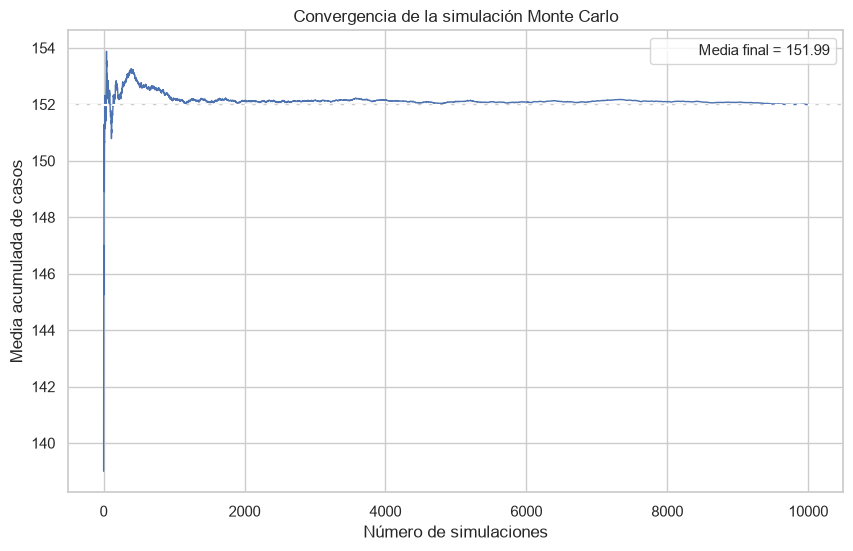

In [69]:
media_acumulada = np.cumsum(casos_simulados) / np.arange(
    1,
    len(casos_simulados) + 1
)

plt.figure(figsize=(10,6))

plt.plot(
    media_acumulada,
    linewidth=1
)

plt.axhline(
    y=casos_simulados.mean(),
    linestyle="--",
    label=f"Media final = {casos_simulados.mean():.2f}"
)

plt.title(
    "Convergencia de la simulación Monte Carlo"
)

plt.xlabel(
    "Número de simulaciones"
)

plt.ylabel(
    "Media acumulada de casos"
)

plt.legend()

plt.show()

In [70]:
print("Media primeras 100 simulaciones:")
print(f"{media_acumulada[99]:.2f}")

print()

print("Media primeras 1.000 simulaciones:")
print(f"{media_acumulada[999]:.2f}")

print()

print("Media primeras 10.000 simulaciones:")
print(f"{media_acumulada[-1]:.2f}")

Media primeras 100 simulaciones:
151.59

Media primeras 1.000 simulaciones:
152.20

Media primeras 10.000 simulaciones:
151.99


### Interpretación

La evolución de la media acumulada muestra que la simulación Monte Carlo converge rápidamente hacia un valor estable. Durante las primeras iteraciones se observan fluctuaciones normales producto de la variabilidad aleatoria inherente al proceso de simulación. Sin embargo, a medida que aumenta el número de simulaciones, dichas fluctuaciones disminuyen progresivamente.

La media acumulada pasó de 151,59 casos en las primeras 100 simulaciones a 152,20 casos en las primeras 1.000 simulaciones y finalmente a 151,99 casos al completar las 10.000 simulaciones. La diferencia entre estos valores es mínima, lo que indica una estabilización efectiva de la estimación.

El gráfico confirma visualmente este comportamiento, observándose que después de aproximadamente 1.000 simulaciones la curva permanece prácticamente horizontal alrededor de 152 casos por cada 1.000 individuos.

Estos resultados permiten concluir que el número de iteraciones utilizado es suficiente para garantizar la convergencia de la simulación y la confiabilidad de las estimaciones obtenidas. Por lo tanto, los resultados de Monte Carlo pueden considerarse estables y adecuados para apoyar la toma de decisiones bajo incertidumbre en el contexto del riesgo cardiovascular estudiado.

# 5. Análisis de robustez

En esta sección se evalúa la sensibilidad de los resultados obtenidos en la Sumativa 1 frente a la presencia de valores extremos.

Para ello se identifican observaciones atípicas mediante el criterio del rango intercuartílico (IQR) y se comparan los principales estadísticos antes y después de su eliminación.

In [71]:
def remove_outliers_iqr(df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

In [72]:
df_robust = df.copy()

for col in ["sysBP", "totChol", "BMI"]:
    df_robust = remove_outliers_iqr(
        df_robust,
        col
    )

print("Observaciones originales :", len(df))
print("Observaciones robustas   :", len(df_robust))
print("Eliminadas               :", len(df)-len(df_robust))

Observaciones originales : 3658
Observaciones robustas   : 3435
Eliminadas               : 223


In [73]:
comparacion_medias = pd.DataFrame({

    "Variable": [
        "Edad",
        "Colesterol",
        "Presión sistólica",
        "IMC"
    ],

    "Original": [
        df["age"].mean(),
        df["totChol"].mean(),
        df["sysBP"].mean(),
        df["BMI"].mean()
    ],

    "Sin outliers": [
        df_robust["age"].mean(),
        df_robust["totChol"].mean(),
        df_robust["sysBP"].mean(),
        df_robust["BMI"].mean()
    ]
})

comparacion_medias.round(2)

,Variable,Original,Sin outliers
0,Edad,49.55,49.21
1,Colesterol,236.85,234.45
2,Presión sistólica,132.37,129.78
3,IMC,25.78,25.42


In [74]:
corr_original = df["sysBP"].corr(
    df["diaBP"]
)

corr_robusta = df_robust["sysBP"].corr(
    df_robust["diaBP"]
)

print(f"Correlación original : {corr_original:.4f}")
print(f"Correlación robusta  : {corr_robusta:.4f}")

Correlación original : 0.7867
Correlación robusta  : 0.7662


### Interpretación

Para evaluar la sensibilidad de los resultados frente a valores extremos, se eliminaron observaciones atípicas en las variables presión sistólica, colesterol total e índice de masa corporal utilizando el criterio del rango intercuartílico (IQR).

Al comparar los estadísticos descriptivos antes y después de la depuración, se observó una disminución moderada en las medias de las variables analizadas. La edad promedio pasó de 49,55 a 49,21 años, el colesterol total de 236,85 a 234,45 mg/dL, la presión sistólica de 132,37 a 129,78 mmHg y el IMC de 25,78 a 25,42 kg/m².

Asimismo, la correlación entre la presión arterial sistólica y diastólica disminuyó levemente de 0,7867 a 0,7662 tras eliminar los valores extremos. Sin embargo, la magnitud y dirección de la asociación permanecieron prácticamente inalteradas, manteniéndose como una correlación positiva fuerte.

En conjunto, estos resultados indican que las principales conclusiones obtenidas en la Sumativa 1 son robustas frente a la presencia de observaciones atípicas. Aunque los valores extremos influyen ligeramente en las estimaciones, no modifican de manera sustancial la interpretación de los resultados ni las relaciones identificadas entre las variables.

# 6. Evaluación del impacto del Listwise Deletion

Durante la Sumativa 1 se eliminaron los registros con valores faltantes mediante la estrategia de Listwise Deletion, reduciendo el tamaño de la muestra desde 4.240 hasta 3.658 observaciones.

Dado que esta estrategia eliminó aproximadamente el 13,7% de los registros originales, resulta importante verificar si los individuos excluidos presentan características sistemáticamente distintas a los conservados.

Para ello se compararán las principales variables demográficas y clínicas entre ambos grupos con el fin de evaluar la representatividad de la muestra final utilizada en los análisis posteriores.

In [75]:
# Cargar nuevamente el dataset original (sin eliminar faltantes)

df_original = pd.read_csv(CSV_FILE)

print("Registros originales :", len(df_original))
print("Registros completos  :", len(df))
print("Registros eliminados :", len(df_original) - len(df))

Registros originales : 4240
Registros completos  : 3658
Registros eliminados : 582


In [76]:
# Identificar registros eliminados por Listwise Deletion

mask_completos = df_original.notna().all(axis=1)

df_completos = df_original[mask_completos].copy()
df_eliminados = df_original[~mask_completos].copy()

print("Completos :", len(df_completos))
print("Eliminados:", len(df_eliminados))

Completos : 3658
Eliminados: 582


In [77]:
comparacion_listwise = pd.DataFrame({

    "Variable": [
        "Edad",
        "Colesterol",
        "Presión sistólica",
        "IMC",
        "% Mujeres",
        "% Diabéticos"
    ],

    "Completos": [
        df_completos["age"].mean(),
        df_completos["totChol"].mean(),
        df_completos["sysBP"].mean(),
        df_completos["BMI"].mean(),
        (1 - df_completos["male"].mean()) * 100,
        df_completos["diabetes"].mean() * 100
    ],

    "Eliminados": [
        df_eliminados["age"].mean(),
        df_eliminados["totChol"].mean(),
        df_eliminados["sysBP"].mean(),
        df_eliminados["BMI"].mean(),
        (1 - df_eliminados["male"].mean()) * 100,
        df_eliminados["diabetes"].mean() * 100
    ]

})

comparacion_listwise.round(2)

,Variable,Completos,Eliminados
0,Edad,49.55,49.76
1,Colesterol,236.85,235.68
2,Presión sistólica,132.37,132.25
3,IMC,25.78,25.92
4,% Mujeres,55.63,66.15
5,% Diabéticos,2.71,1.72


In [78]:
comparacion_listwise["Diferencia (%)"] = (
    (
        comparacion_listwise["Eliminados"]
        - comparacion_listwise["Completos"]
    )
    / comparacion_listwise["Completos"]
    * 100
)

comparacion_listwise.round(2)

,Variable,Completos,Eliminados,Diferencia (%)
0,Edad,49.55,49.76,0.42
1,Colesterol,236.85,235.68,-0.49
2,Presión sistólica,132.37,132.25,-0.09
3,IMC,25.78,25.92,0.52
4,% Mujeres,55.63,66.15,18.91
5,% Diabéticos,2.71,1.72,-36.51


### Interpretación

Se compararon las principales características de los registros conservados y de aquellos eliminados durante el proceso de Listwise Deletion con el objetivo de evaluar el posible impacto de la eliminación de datos faltantes.

Las variables cuantitativas presentaron diferencias muy pequeñas entre ambos grupos. La edad promedio varió solo un 0,42%, el colesterol total un -0,49%, la presión arterial sistólica un -0,09% y el IMC un 0,52%, lo que indica que las características clínicas generales permanecen prácticamente inalteradas tras la depuración de los datos.

En las variables categóricas se observó una mayor proporción de mujeres y una menor proporción de pacientes diabéticos entre los registros eliminados. No obstante, considerando que únicamente se eliminó el 13,7% de la muestra original y que las principales variables continuas mantienen valores muy similares, no existe evidencia de un cambio sustancial en la composición general del conjunto de datos.

En consecuencia, el procedimiento de Listwise Deletion no parece haber introducido un sesgo importante en la muestra utilizada para los análisis estadísticos posteriores, proporcionando mayor confianza en la representatividad del conjunto de datos final.

# 7. Preparación para la Sumativa 3

La Evaluación Sumativa 3 tendrá como objetivo profundizar el análisis del problema mediante técnicas estadísticas y modelos más avanzados. Por esta razón, resulta fundamental identificar cuáles de los resultados obtenidos hasta ahora pueden considerarse confiables y cuáles requieren un análisis más cuidadoso.

Las técnicas de remuestreo, simulación y análisis de robustez aplicadas en esta Sumativa permitieron validar los principales hallazgos de la Sumativa 1, evaluar la estabilidad de las correlaciones observadas y analizar el impacto de los valores extremos sobre las conclusiones obtenidas.

A continuación, se presenta una síntesis de los parámetros, asociaciones y resultados que demostraron mayor estabilidad estadística y que constituyen la base metodológica para la siguiente etapa del proyecto.

In [79]:
resumen_s3 = pd.DataFrame({

    "Elemento": [
        "Edad promedio",
        "Colesterol total",
        "Presión sistólica",
        "Proporción CHD",
        "Correlación sysBP-diaBP",
        "Correlación age-sysBP",
        "Correlación age-CHD",
        "Listwise Deletion"
    ],

    "Estado": [
        "Robusto",
        "Robusto",
        "Robusto",
        "Robusto",
        "Estable",
        "Estable",
        "Estable",
        "Validado"
    ],

    "Observación": [
        "Bootstrap consistente con IC clásico",
        "Bootstrap consistente con IC clásico",
        "Bootstrap consistente con IC clásico",
        "Wilson y Bootstrap coinciden",
        "IC bootstrap no incluye 0",
        "IC bootstrap no incluye 0",
        "IC bootstrap no incluye 0",
        "Muestra final comparable con la original"
    ]
})

resumen_s3

,Elemento,Estado,Observación
0,Edad promedio,Robusto,Bootstrap consistente con IC clásico
1,Colesterol total,Robusto,Bootstrap consistente con IC clásico
2,Presión sistólica,Robusto,Bootstrap consistente con IC clásico
3,Proporción CHD,Robusto,Wilson y Bootstrap coinciden
4,Correlación sysBP-diaBP,Estable,IC bootstrap no incluye 0
5,Correlación age-sysBP,Estable,IC bootstrap no incluye 0
6,Correlación age-CHD,Estable,IC bootstrap no incluye 0
7,Listwise Deletion,Validado,Muestra final comparable con la original


## Preparación para la Sumativa 3

Los análisis de remuestreo, simulación y robustez realizados permitieron validar los principales resultados obtenidos en la Sumativa 1.

Las estimaciones de edad, colesterol total, presión sistólica y proporción de enfermedad coronaria mostraron alta estabilidad frente a técnicas bootstrap, obteniéndose intervalos de confianza consistentes con los métodos clásicos utilizados previamente.

Las correlaciones seleccionadas presentaron intervalos bootstrap que no incluyen el valor cero, lo que indica asociaciones estables entre las variables analizadas. Destaca especialmente la relación entre presión sistólica y presión diastólica, que mantuvo una correlación fuerte incluso después de eliminar observaciones atípicas.

El análisis de robustez evidenció que la eliminación de valores extremos produce cambios menores en las estimaciones y correlaciones principales, por lo que las conclusiones obtenidas pueden considerarse confiables para etapas posteriores del proyecto.

Como recomendación metodológica para la Sumativa 3, se sugiere priorizar variables que demostraron estabilidad estadística y relevancia clínica, tales como edad, presión arterial, colesterol total e índice de masa corporal, debido a su asociación consistente con el riesgo cardiovascular observado en el estudio.

Asimismo, la evaluación del impacto del proceso de limpieza permitió verificar que la eliminación de registros incompletos no altera sustancialmente la composición de la muestra analizada, aumentando la confianza en la representatividad del conjunto de datos utilizado durante el proyecto.